In [10]:
!nvidia-smi

Mon Jul 20 11:54:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             11W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
HOME = os.getcwd()
print(HOME)

/content


## Install YOLOv8

⚠️ YOLOv8 is still under heavy development. Breaking changes are being introduced almost weekly. We strive to make our YOLOv8 notebooks work with the latest version of the library. Last tests took place on **18.01.2023** with version **YOLOv8.0.9**.

If you notice that our notebook behaves incorrectly - especially if you experience errors that prevent you from going through the tutorial - don't hesitate! Let us know and open an [issue](https://github.com/roboflow/notebooks/issues) on the Roboflow Notebooks repository.

YOLOv8 can be installed in two ways - from the source and via pip. This is because it is the first iteration of YOLO to have an official package.

In [11]:
# Pip install method (recommended)
!pip install ultralytics

from IPython import display
display.clear_output()

import ultralytics
ultralytics.checks()

Ultralytics 8.4.102 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 46.8/112.6 GB disk)


In [12]:
from ultralytics import YOLO
from IPython.display import display, Image

If you want to train, validate or run inference on models and don't need to make any modifications to the code, using YOLO command line interface is the easiest way to get started. Read more about CLI in [Ultralytics YOLO Docs](https://v8docs.ultralytics.com/cli/).

```
yolo task=detect    mode=train    model=yolov8n.yaml      args...
          classify       predict        yolov8n-cls.yaml  args...
          segment        val            yolov8n-seg.yaml  args...
                         export         yolov8n.pt        format=onnx  args...
```

# Custom Training

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
%pwd

'/content/drive/My Drive'

In [18]:
%cd /content/drive/MyDrive/construction_data

/content/drive/MyDrive/construction_data


In [19]:
%ls

construction_data.zip


In [20]:
!unzip /content/drive/MyDrive/construction_data/construction_data.zip

Archive:  /content/drive/MyDrive/construction_data/construction_data.zip
  inflating: data.yaml               
   creating: test/
   creating: test/images/
  inflating: test/images/1.jpeg      
  inflating: test/images/10.jpeg     
  inflating: test/images/11.jpeg     
  inflating: test/images/12.jpeg     
  inflating: test/images/13.jpeg     
  inflating: test/images/14(1).jpeg  
  inflating: test/images/14.jpg      
  inflating: test/images/15.jpeg     
  inflating: test/images/16.jpeg     
  inflating: test/images/17.jpeg     
  inflating: test/images/18.jpeg     
  inflating: test/images/19.jpeg     
  inflating: test/images/2.jpeg      
  inflating: test/images/20.jpeg     
  inflating: test/images/21.jpeg     
  inflating: test/images/22.jpeg     
  inflating: test/images/23.jpeg     
  inflating: test/images/24.jpeg     
  inflating: test/images/25.jpeg     
  inflating: test/images/26.jpeg     
  inflating: test/images/27.jpeg     
  inflating: test/images/28.jpeg     
  inflat

In [21]:
%ls

construction_data.zip  data.yaml  test/  train/  valid/


In [25]:
%cd /content/drive/MyDrive/construction_data
!yolo task=detect mode=train model=yolov8s.pt data= data.yaml epochs=25 imgsz=224 plots=True

/content/drive/MyDrive/construction_data
Ultralytics 8.4.102 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-4, nbs=64, nms=False, opset=None, optimize=False, optimiz

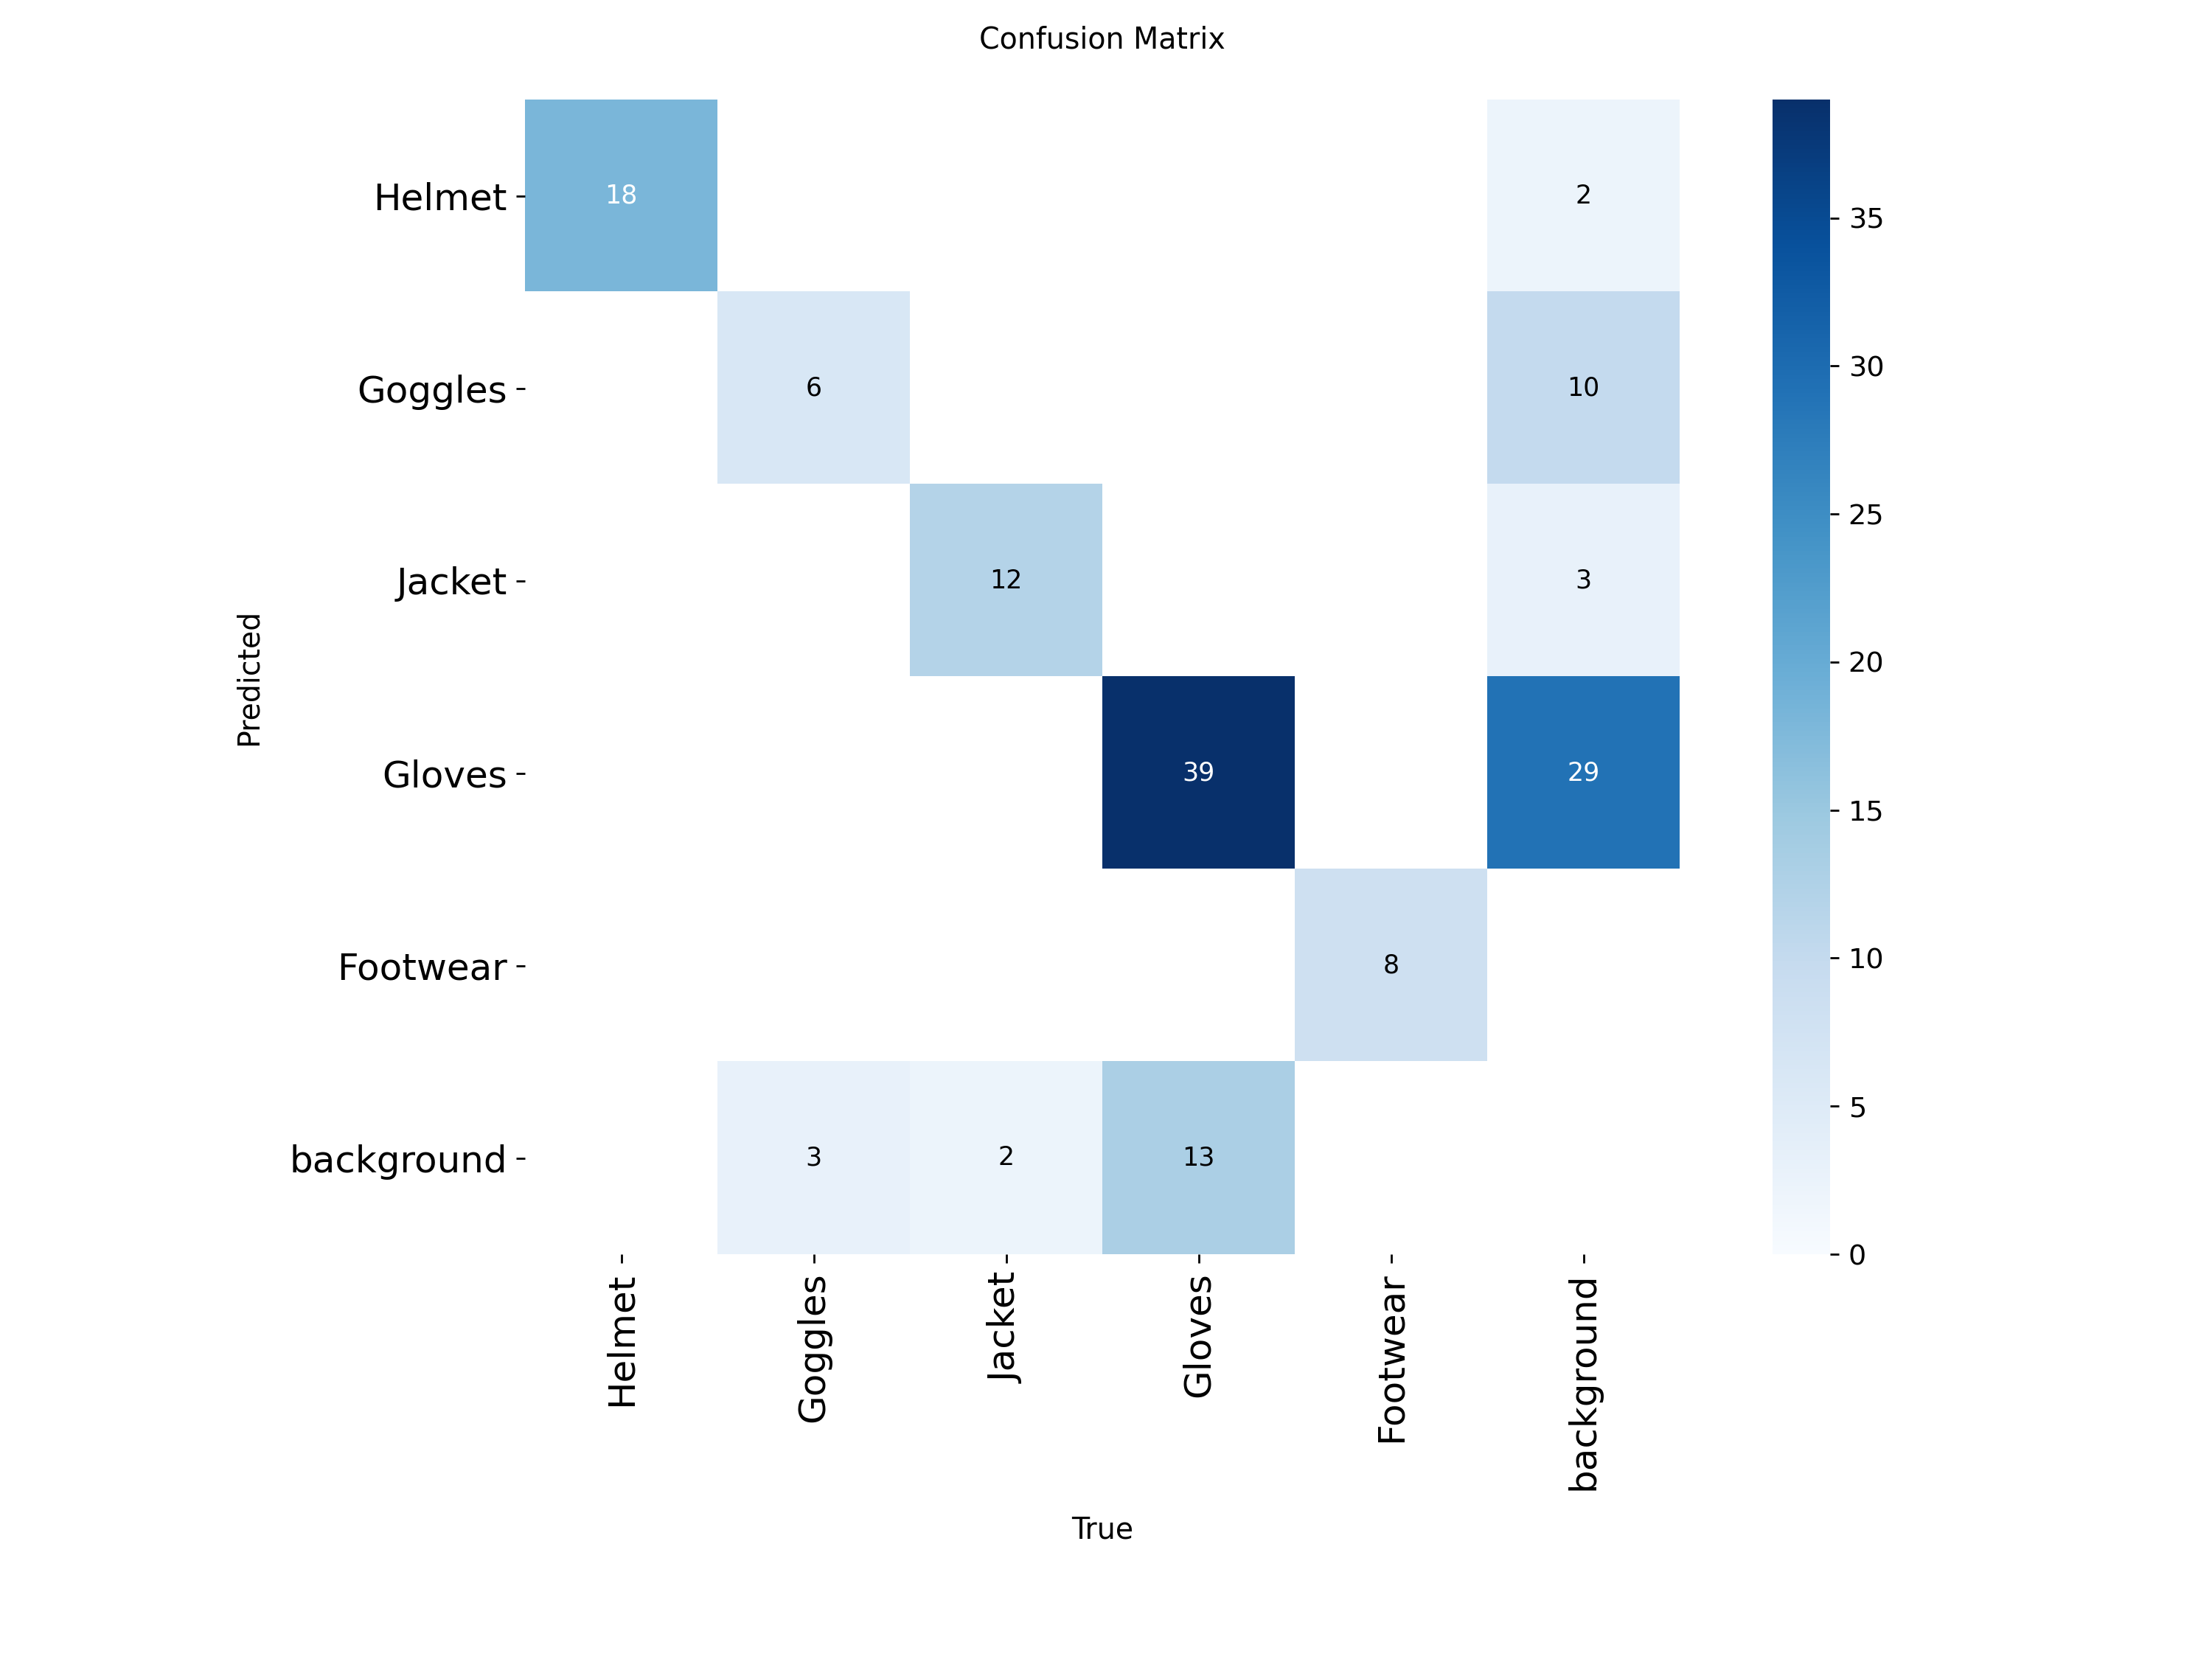

In [26]:
Image(filename='/content/drive/MyDrive/construction_data/runs/detect/train-4/confusion_matrix.png', width=600)

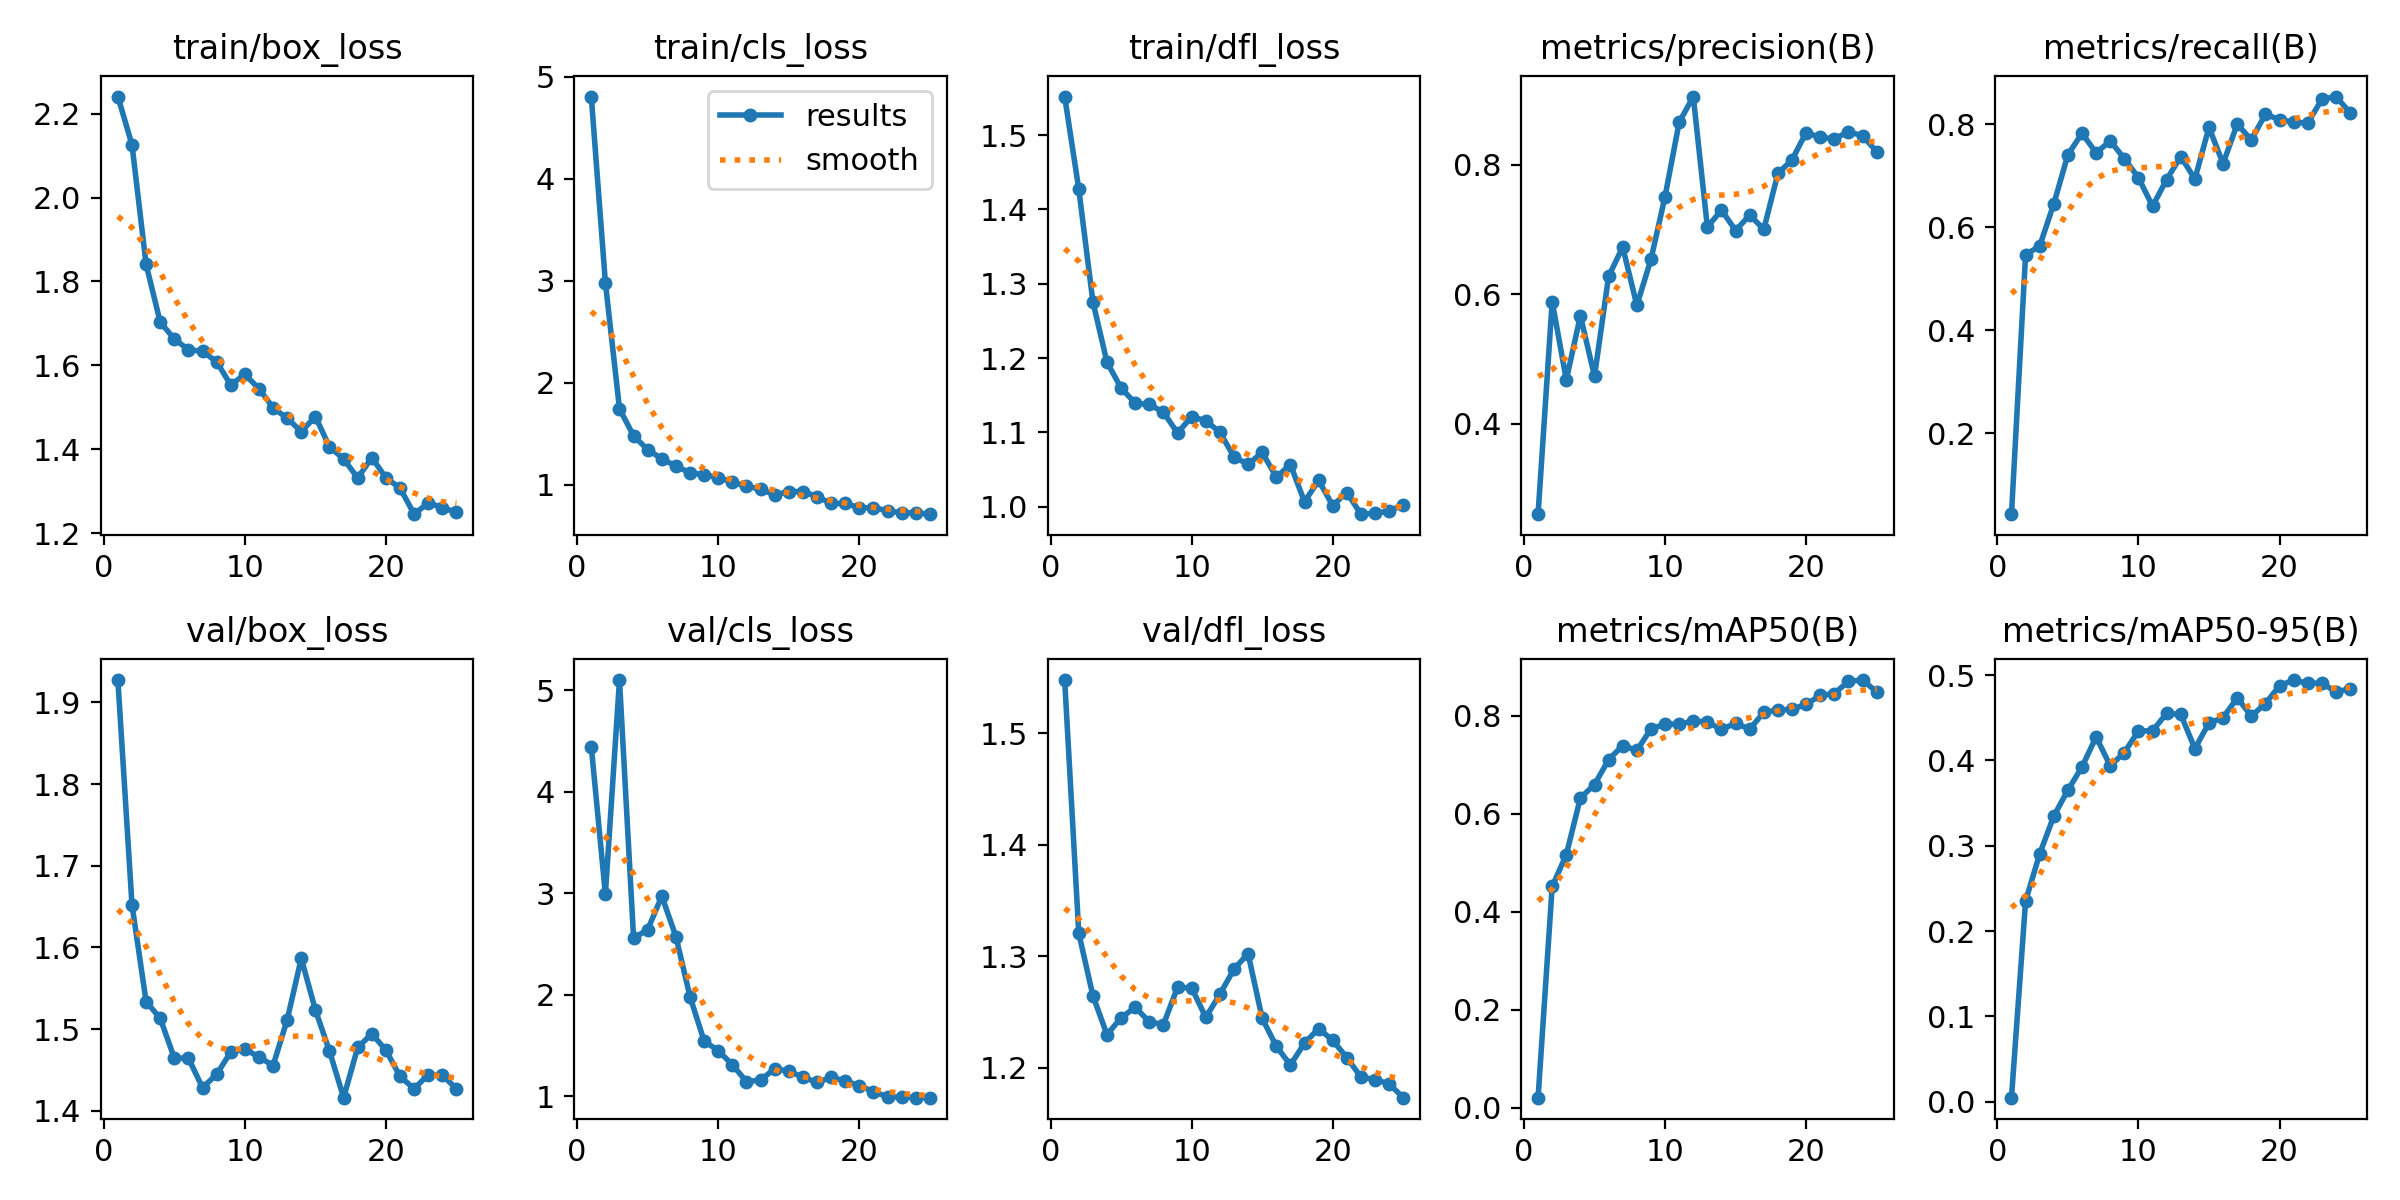

In [27]:
Image(filename='/content/drive/MyDrive/construction_data/runs/detect/train-4/results.png', width=600)

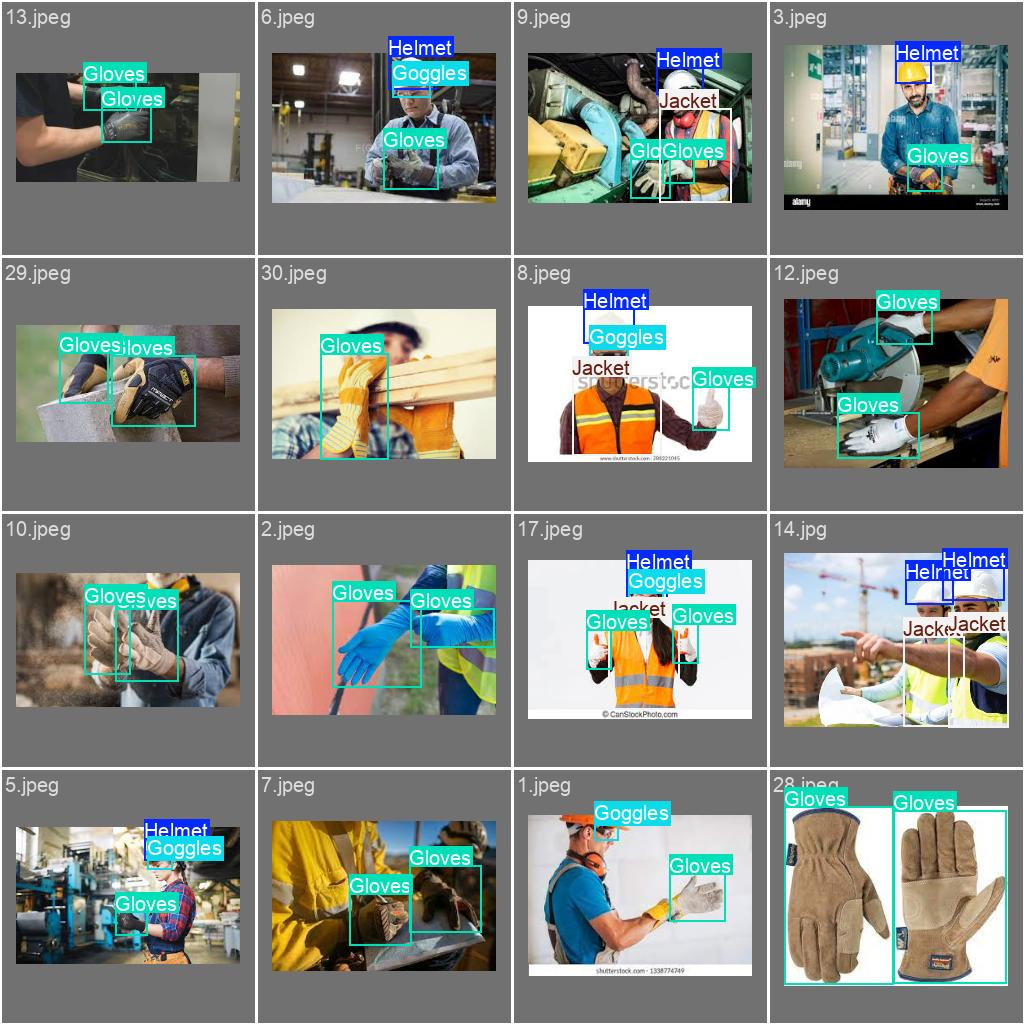

In [28]:
Image(filename='/content/drive/MyDrive/construction_data/runs/detect/train-4/val_batch0_labels.jpg', width=600)

## Validate Custom Model

In [29]:
!yolo task=detect mode=val model="/content/drive/MyDrive/construction_data/runs/detect/train-4/weights/best.pt" data=data.yaml

Ultralytics 8.4.102 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,519 parameters, 0 gradients, 28.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.6±0.3 ms, read: 4.9±1.7 MB/s, size: 8.2 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/construction_data/valid/labels.cache... 31 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 31/31 5.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 3.7it/s 0.5s
                   all         31        101      0.845      0.794       0.85      0.501
                Helmet         17         18      0.936          1      0.995      0.692
               Goggles          9          9       0.66      0.556      0.642      0.323
                Jacket         13         14      0.886 

## Inference with Custom Model

In [30]:
!yolo task=detect mode=predict model="/content/drive/MyDrive/construction_data/runs/detect/train-4/weights/best.pt" conf=0.25 source="/content/drive/MyDrive/construction_data/test/images"

Ultralytics 8.4.102 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,519 parameters, 0 gradients, 28.4 GFLOPs

image 1/31 /content/drive/MyDrive/construction_data/test/images/1.jpeg: 192x224 1 Goggles, 3 Glovess, 60.2ms
image 2/31 /content/drive/MyDrive/construction_data/test/images/10.jpeg: 160x224 5 Glovess, 46.0ms
image 3/31 /content/drive/MyDrive/construction_data/test/images/11.jpeg: 224x224 5 Glovess, 8.4ms
image 4/31 /content/drive/MyDrive/construction_data/test/images/12.jpeg: 192x224 1 Gloves, 8.9ms
image 5/31 /content/drive/MyDrive/construction_data/test/images/13.jpeg: 128x224 1 Gloves, 45.2ms
image 6/31 /content/drive/MyDrive/construction_data/test/images/14(1).jpeg: 224x224 3 Glovess, 9.7ms
image 7/31 /content/drive/MyDrive/construction_data/test/images/14.jpg: 192x224 2 Helmets, 2 Glovess, 8.8ms
image 8/31 /content/drive/MyDrive/construction_data/test/images/15.jpeg: 224x224 2 Jackets, 4 Glovess, 11.1ms
image 9/31 /c